# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: PURE DINOv2 (ViT + SwAV + iBOT + KoLeo) on: cuda
Loading Data/network_connections.csv...

--- PHASE A: PREPROCESSING (PURE) ---

--- PHASE 1: PRETRAINING (DINO + iBOT + Sinkhorn) ---
Epoch 1 | Total: 6.3118 | DINO: 5.9236 | iBOT: 0.7094
Epoch 2 | Total: 5.4753 | DINO: 5.2301 | iBOT: 0.4564
Epoch 3 | Total: 5.0662 | DINO: 4.8400 | iBOT: 0.4235
Epoch 4 | Total: 4.8480 | DINO: 4.6155 | iBOT: 0.4400
Epoch 5 | Total: 4.6737 | DINO: 4.4622 | iBOT: 0.4032
Epoch 6 | Total: 4.5731 | DINO: 4.3438 | iBOT: 0.4417
Epoch 7 | Total: 4.4847 | DINO: 4.2585 | iBOT: 0.4373
Epoch 8 | Total: 4.4101 | DINO: 4.1886 | iBOT: 0.4306
Epoch 9 | Total: 4.3068 | DINO: 4.1140 | iBOT: 0.3755
Epoch 10 | Total: 4.2724 | DINO: 4.0546 | iBOT: 0.4265
Epoch 11 | Total: 4.1792 | DINO: 3.9972 | iBOT: 0.3565
Epoch 12 | Total: 4.1867 | DINO: 3.9504 | iBOT: 0.4657
Epoch 13 | Total: 4.1106 | DINO: 3.9114 | iBOT: 0.3926
Epoch 14 | Total: 4.0860 | DINO: 3.8771 | iBOT: 0.4125
Epoch 15 | Total: 4.0439 | DINO: 3.8546 | iB

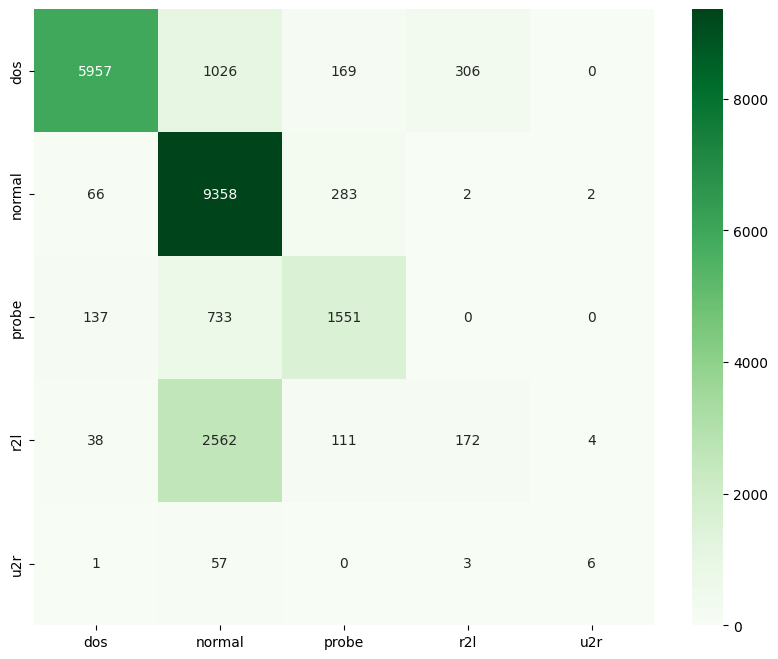

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler_amp = torch.cuda.amp.GradScaler()
print(f"🚀 PIPELINE: PURE DINOv2 (ViT + SwAV + iBOT + KoLeo) on: {device}")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_and_prep(path):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    # Minimal Feature Engineering (Just Ratios)
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

# Load Data
X, y = load_and_prep('Data/network_connections.csv')
le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)
train_cols = X.columns.tolist()

# Clean up
del X, y
gc.collect()

# ==========================================
# 2. FEATURE ENGINEERING (Refactored)
# ==========================================
print("\n--- PHASE A: PREPROCESSING (PURE) ---")
# Only Standard Scaling is allowed in SSL.
# No NCA (Cheating/Supervised), No IsoForest (Redundant).
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_raw).astype(np.float32)

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

del X_train_raw
gc.collect()

# ==========================================
# 3. ADVANCED LOSS COMPONENTS
# ==========================================

# --- A. KoLeo Loss (Regularization) ---
class KoLeoLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, student_output, eps=1e-8):
        x = F.normalize(student_output, p=2, dim=1)
        dots = torch.mm(x, x.t())
        dots.view(-1)[::x.shape[0]+1] = -float('inf') 
        _, I = torch.max(dots, dim=1)
        nearest_neighbor = x[I]
        dot_product = (x * nearest_neighbor).sum(dim=1)
        loss = -torch.log(torch.sqrt(2 * (1 - dot_product + eps)) + eps).mean()
        return loss

# --- B. Sinkhorn-Knopp (SwAV Clustering) ---
class SinkhornKnopp(nn.Module):
    def __init__(self, num_prototypes, epsilon=0.05, iterations=3, use_queue=True, queue_size=2048):
        super().__init__()
        self.epsilon = epsilon
        self.iterations = iterations
        self.use_queue = use_queue
        if use_queue:
            self.register_buffer("queue", torch.randn(queue_size, num_prototypes))
            self.queue = F.normalize(self.queue, dim=1)
            self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def update_queue(self, teacher_output):
        if not self.use_queue: return
        batch_size = teacher_output.shape[0]
        ptr = int(self.queue_ptr)
        if ptr + batch_size <= self.queue.shape[0]:
            self.queue[ptr:ptr+batch_size] = teacher_output
        else:
            rem = self.queue.shape[0] - ptr
            self.queue[ptr:] = teacher_output[:rem]
        self.queue_ptr[0] = (ptr + batch_size) % self.queue.shape[0]

    @torch.no_grad()
    def forward(self, teacher_output):
        teacher_output = teacher_output.float()
        if self.use_queue:
            full_support = torch.cat([teacher_output, self.queue.clone().detach().float()], dim=0)
        else:
            full_support = teacher_output

        Q = torch.exp(full_support / self.epsilon).t()
        B = Q.shape[1]; K = Q.shape[0]
        sum_Q = torch.sum(Q); Q /= sum_Q

        for _ in range(self.iterations):
            Q /= torch.sum(Q, dim=1, keepdim=True); Q /= K
            Q /= torch.sum(Q, dim=0, keepdim=True); Q /= B
        Q *= B
        return Q.t()[:teacher_output.shape[0]]

# ==========================================
# 4. ARCHITECTURE: DINOv2 + iBOT
# ==========================================

class TabularPatchEmbed(nn.Module):
    def __init__(self, num_features, embed_dim):
        super().__init__()
        # Feature Tokenizer: Each feature gets a unique embedding vector
        self.proj = nn.Parameter(torch.randn(num_features, embed_dim) / np.sqrt(embed_dim))
        self.bias = nn.Parameter(torch.zeros(num_features, embed_dim))
    
    def forward(self, x):
        # x: [Batch, Num_Features]
        # output: [Batch, Num_Features, Embed_Dim]
        return x.unsqueeze(-1) * self.proj.unsqueeze(0) + self.bias.unsqueeze(0)

class TabularViT(nn.Module):
    def __init__(self, input_dim, embed_dim=64, depth=4, num_registers=4):
        super().__init__()
        self.patch_embed = TabularPatchEmbed(input_dim, embed_dim)
        
        # DINOv2: Registers + CLS
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.registers = nn.Parameter(torch.zeros(1, num_registers, embed_dim))
        
        enc = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=256, 
                                         batch_first=True, norm_first=True, activation='gelu', dropout=0.0)
        self.transformer = nn.TransformerEncoder(enc, num_layers=depth)

    def forward(self, x):
        x_emb = self.patch_embed(x) # [B, N_Feat, Dim]
        b = x.shape[0]
        
        cls_tokens = self.cls_token.expand(b, -1, -1)
        regs = self.registers.expand(b, -1, -1)
        
        # Concat: [CLS, Regs, Features]
        x_seq = torch.cat((cls_tokens, regs, x_emb), dim=1)
        x_out = self.transformer(x_seq)
        
        # Return CLS for DINO head, and Feature tokens for MIM head
        # CLS is at 0. Registers are 1..R. Features are R+1...end.
        return x_out[:, 0, :], x_out[:, 1+self.registers.shape[1]:, :]

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=256, bottleneck_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)

class MIMHead(nn.Module):
    """Masked Image Modeling Head (Reconstructs original scalar values)"""
    def __init__(self, embed_dim):
        super().__init__()
        # Projects embedding back to a single scalar value
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )
    def forward(self, x_seq):
        # x_seq: [Batch, Num_Features, Embed_Dim]
        # output: [Batch, Num_Features] (Squeezed last dim)
        return self.decoder(x_seq).squeeze(-1)

# ==========================================
# 5. DATA COLLATOR (MASKING)
# ==========================================
class TabularMIMCollator:
    def __init__(self, mask_ratio=0.4, noise=0.05):
        self.mask_ratio = mask_ratio
        self.noise = noise
        
    def __call__(self, batch):
        x = torch.stack([item[0] for item in batch])
        y = torch.stack([item[1] for item in batch])
        
        # Teacher: Global View (Clean, minor noise)
        x_teacher = x.clone() + torch.randn_like(x) * self.noise
        
        # Student: Local View (Masked)
        # Create binary mask (1 = masked, 0 = visible)
        mask = torch.rand_like(x) < self.mask_ratio
        
        x_student = x.clone()
        x_student[mask] = 0 # Mask token is Zero
        x_student = x_student + torch.randn_like(x) * self.noise
        
        return x_teacher, x_student, mask, y

# ==========================================
# 6. TRAINING LOOP
# ==========================================
BATCH_SIZE = 64
GRAD_ACCUM = 4
EMBED_DIM = 64
NUM_PROTOTYPES = 1024

# Models
student_enc = TabularViT(X_train_final.shape[1], EMBED_DIM).to(device)
student_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)
student_mim = MIMHead(EMBED_DIM).to(device) # New iBOT Head

teacher_enc = TabularViT(X_train_final.shape[1], EMBED_DIM).to(device)
teacher_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)

# Sync Teacher
teacher_enc.load_state_dict(student_enc.state_dict())
teacher_dino.load_state_dict(student_dino.state_dict())
for p in teacher_enc.parameters(): p.requires_grad = False
for p in teacher_dino.parameters(): p.requires_grad = False

# Losses & Opt
sinkhorn = SinkhornKnopp(NUM_PROTOTYPES, use_queue=True, queue_size=2048).to(device)
koleo = KoLeoLoss().to(device)
optimizer = optim.AdamW(
    list(student_enc.parameters()) + list(student_dino.parameters()) + list(student_mim.parameters()), 
    lr=0.001, weight_decay=1e-4
)

# Data
collator = TabularMIMCollator(mask_ratio=0.5)
train_dl = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                      batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator, drop_last=True)

def update_teacher(m):
    with torch.no_grad():
        for ps, pt in zip(student_enc.parameters(), teacher_enc.parameters()):
            pt.data = pt.data * m + ps.data * (1 - m)
        for ps, pt in zip(student_dino.parameters(), teacher_dino.parameters()):
            pt.data = pt.data * m + ps.data * (1 - m)

# --- PHASE 1: PRETRAINING ---
print("\n--- PHASE 1: PRETRAINING (DINO + iBOT + Sinkhorn) ---")
for epoch in range(15):
    student_enc.train(); student_dino.train(); student_mim.train()
    loss_total = 0
    loss_dino_log = 0
    loss_mim_log = 0
    m = 0.996 + (1.0 - 0.996) * (epoch / 15)
    
    optimizer.zero_grad()
    for i, (x_t, x_s, mask, _) in enumerate(train_dl):
        x_t, x_s, mask = x_t.to(device), x_s.to(device), mask.to(device)
        
        with torch.cuda.amp.autocast():
            # 1. Forward Student
            s_cls, s_seq = student_enc(x_s)
            s_dino_out = student_dino(s_cls)
            s_rec = student_mim(s_seq) # Reconstruct features
            
            # 2. Forward Teacher
            with torch.no_grad():
                t_cls, _ = teacher_enc(x_t)
                t_dino_out = teacher_dino(t_cls)
            
            # 3. Calculate Losses
            # A. DINO Loss (Cluster Matching)
            t_targets = sinkhorn(t_dino_out)
            l_dino = -torch.sum(t_targets * F.log_softmax(s_dino_out / 0.1, dim=-1), dim=-1).mean()
            
            # B. iBOT/MIM Loss (Reconstruction)
            # Only calculate MSE on the masked elements
            # x_t is the "Ground Truth" (Clean input)
            l_mim = F.mse_loss(s_rec[mask], x_t[mask])
            
            # C. KoLeo (Regularization)
            l_koleo = koleo(s_cls)
            
            # Combine
            loss = (l_dino + 0.5 * l_mim + 0.1 * l_koleo) / GRAD_ACCUM
        
        scaler_amp.scale(loss).backward()
        
        if (i+1) % GRAD_ACCUM == 0:
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad()
            update_teacher(m)
            sinkhorn.update_queue(t_dino_out)
            
        loss_total += loss.item() * GRAD_ACCUM
        loss_dino_log += l_dino.item()
        loss_mim_log += l_mim.item()
        
    print(f"Epoch {epoch+1} | Total: {loss_total/len(train_dl):.4f} | DINO: {loss_dino_log/len(train_dl):.4f} | iBOT: {loss_mim_log/len(train_dl):.4f}")

# --- PHASE 2: LINEAR PROBE ---
print("\n--- PHASE 2: LINEAR PROBE TRAINING ---")
for p in student_enc.parameters(): p.requires_grad = False
student_cls = nn.Linear(EMBED_DIM, num_classes).to(device)
opt_lin = optim.AdamW(student_cls.parameters(), lr=0.005)
crit_ce = nn.CrossEntropyLoss()
train_dl_lin = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

for epoch in range(10):
    student_cls.train()
    loss_acc = 0
    for x, y in train_dl_lin:
        x, y = x.to(device), y.to(device)
        with torch.no_grad(): 
            feat, _ = student_enc(x) # Get CLS
        logits = student_cls(feat)
        loss = crit_ce(logits, y)
        opt_lin.zero_grad(); loss.backward(); opt_lin.step()
        loss_acc += loss.item()
    print(f"Probe Epoch {epoch+1} | Loss: {loss_acc/len(train_dl_lin):.4f}")

# ==========================================
# 6. EVALUATION
# ==========================================
print("\n--- PHASE E: FINAL EVALUATION ---")
# Standard NSL Loading for Test
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']
df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')

# Same minimal prep
if 'src_bytes' in df_nsl.columns:
    df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
    df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
    if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])

df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
for c in train_cols:
    if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]

y_nsl_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
X_nsl_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
X_test_tensor_cpu = torch.tensor(X_nsl_sc)

# Eval Loop
def predict_batched(model, x_cpu):
    model.eval()
    x_gpu = x_cpu.to(device)
    with torch.no_grad():
        s_cls, _ = model(x_gpu)
        logits = student_cls(s_cls)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

all_probs = []
loader = DataLoader(TensorDataset(X_test_tensor_cpu), batch_size=2048)
for bx in loader:
    p = predict_batched(student_enc, bx[0]) 
    all_probs.append(p)
probs_np = np.concatenate(all_probs)

final_preds = np.argmax(probs_np, axis=1)
mask = y_nsl_vec != -1

acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
mcc = matthews_corrcoef(y_nsl_vec[mask], final_preds[mask])

print("\n" + "="*40)
print(f" 👑 FINAL RESULTS (Pure DINOv2): {acc:.2%} (MCC: {mcc:.4f}) 👑")
print("="*40)
print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))

labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
label_names = [le.classes_[i] for i in labels]
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
            annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
plt.show()